In [1]:
import pandas as pd
import polars as pl
import numpy as np
import matplotlib.pyplot as plt
import gc

from sklearn.model_selection import train_test_split
from sklearn.metrics import classification_report, accuracy_score, confusion_matrix, recall_score, precision_score, f1_score,\
    confusion_matrix, ConfusionMatrixDisplay, average_precision_score

from catboost import CatBoostClassifier
from catboost import utils

In [2]:
train_part1 = pd.read_parquet("../ClearData/train_full.parquet")
train_part1.shape

(85677840, 14)

In [3]:
pos_class = train_part1.loc[train_part1["target"] == 1]
pos_class.shape

(51438, 14)

In [4]:
train_part1 = train_part1.loc[train_part1["target"] != 1]
train_part1.shape

(85626402, 14)

In [5]:
neg_class = 15_000_000
train_part1 = train_part1.sample(n=neg_class)
train_part1 = pd.concat([train_part1, pos_class])
train_part1 = train_part1.sample(frac=1).reset_index(drop=True)
train_part1.shape

(15051438, 14)

In [6]:
x = train_part1.drop(columns="target")
y = train_part1["target"]

In [7]:
X_train, X_test, y_train, y_test = train_test_split(x, y, test_size=0.1, stratify=y) 

In [8]:
def train_models(model, X_train, X_test, y_train, y_test, sample_weight=None):      # This function training model and output accuracy metrics
    if (sample_weight is None):
        model.fit(X_train, y_train)
    else:
        model.fit(X_train, y_train, sample_weight=sample_weight)
        
    predict_train = model.predict(X_train)
    print(f"Train metrics:")
    print(f"Accuracy: {accuracy_score(y_true=y_train, y_pred=predict_train)}")
    print(f"Precision: {precision_score(y_true=y_train, y_pred=predict_train)}")
    print(f"Recall: {recall_score(y_true=y_train, y_pred=predict_train)}")
    print(f"F1-score: {f1_score(y_true=y_train, y_pred=predict_train)}")
    y_pred_proba = model.predict_proba(X_train)[:, 1]
    print(f"PR-AUC: {average_precision_score(y_true=y_train, y_score=y_pred_proba)}\n")

    predict_test = model.predict(X_test)
    print(f"Test metrics:")
    print(f"Accuracy: {accuracy_score(y_true=y_test, y_pred=predict_test)}")
    print(f"Precision: {precision_score(y_true=y_test, y_pred=predict_test)}")
    print(f"Recall: {recall_score(y_true=y_test, y_pred=predict_test)}")
    print(f"F1-score: {f1_score(y_true=y_test, y_pred=predict_test)}")
    y_pred_proba = model.predict_proba(X_test)[:, 1]
    print(f"PR-AUC: {average_precision_score(y_true=y_test, y_score=y_pred_proba)}\n")

    print("Confusion matrix")
    cm = confusion_matrix(y_true=y_test, y_pred=predict_test, labels=model.classes_)
    disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=model.classes_)    
    disp.plot()

In [9]:
weights = 100
CatBoost = CatBoostClassifier(iterations=1000, depth=5, scale_pos_weight=weights, verbose=False)

Train metrics:
Accuracy: 0.9565998278702673
Precision: 0.03475803122347342
Recall: 0.4370309887631712
F1-score: 0.06439461754953846
PR-AUC: 0.052503289599040964

Test metrics:
Accuracy: 0.9565888712309254
Precision: 0.03540997777228946
Recall: 0.44595645412130636
F1-score: 0.06561034206612516
PR-AUC: 0.054706155121541936

Confusion matrix


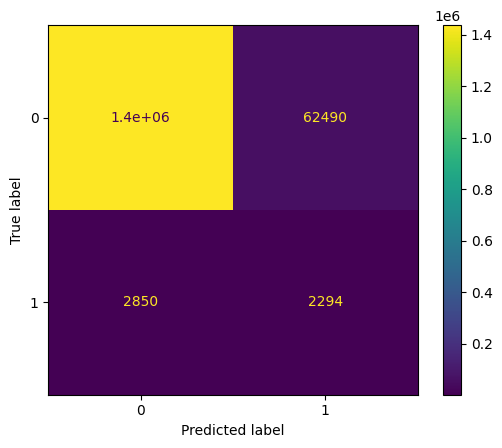

In [10]:
train_models(CatBoost, x, X_test, y, y_test)

In [11]:
CatBoost.save_model('../Models/Model_3.cbm')